# <center>Symptom-Based Illness Prediction Using Ensemble Deep Learning Models with Mobile API Deployment</center>
## <center>Mike Ayiko</center>
## <center>20241201555</center>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import math

import warnings
warnings.filterwarnings('ignore')

# **1. Data Wrangling**

## **1.1  Load and Initial Inspection**

In [2]:
# Load the dataset
df = pd.read_csv('Training.csv')

df.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis,Unnamed: 133
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN


In [3]:
df_test=pd.read_csv("Testing.csv")
df_test.shape

(42, 133)

In [4]:
df_test.head(42)

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,0,0,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Allergy
2,0,0,0,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,GERD
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Chronic cholestasis
4,1,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,Drug Reaction
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Peptic ulcer diseae
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,AIDS
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Diabetes
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Gastroenteritis
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Bronchial Asthma


In [5]:
# Basic information
print("Dataset shape:", df.shape)


Dataset shape: (4920, 134)


In [6]:
print("\nFirst 5 rows:")
print(df.head())



First 5 rows:
   itching  skin_rash  nodal_skin_eruptions  continuous_sneezing  shivering  \
0        1          1                     1                    0          0   
1        0          1                     1                    0          0   
2        1          0                     1                    0          0   
3        1          1                     0                    0          0   
4        1          1                     1                    0          0   

   chills  joint_pain  stomach_pain  acidity  ulcers_on_tongue  ...  scurring  \
0       0           0             0        0                 0  ...         0   
1       0           0             0        0                 0  ...         0   
2       0           0             0        0                 0  ...         0   
3       0           0             0        0                 0  ...         0   
4       0           0             0        0                 0  ...         0   

   skin_peeling  silver

In [7]:
print("\nData types:")
print(df.dtypes.value_counts())



Data types:
int64      132
object       1
float64      1
Name: count, dtype: int64


In [8]:
print("\nMissing values per column:")
print(df.isnull().sum().sum())  # total missing


Missing values per column:
4920


The missing values are due to column `Unnamed: 133` since there are $4920$ observations

In [9]:
# Let's drop the column
del df['Unnamed: 133']   

In [10]:
print(df.head())

   itching  skin_rash  nodal_skin_eruptions  continuous_sneezing  shivering  \
0        1          1                     1                    0          0   
1        0          1                     1                    0          0   
2        1          0                     1                    0          0   
3        1          1                     0                    0          0   
4        1          1                     1                    0          0   

   chills  joint_pain  stomach_pain  acidity  ulcers_on_tongue  ...  \
0       0           0             0        0                 0  ...   
1       0           0             0        0                 0  ...   
2       0           0             0        0                 0  ...   
3       0           0             0        0                 0  ...   
4       0           0             0        0                 0  ...   

   blackheads  scurring  skin_peeling  silver_like_dusting  \
0           0         0             

In [11]:
print("\nMissing values per column:")
print(df.isnull().sum().sum())  # total missing


Missing values per column:
0


## **1.2 Check for Duplicates**

In [12]:
# Duplicate rows in features + target
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")



Duplicate rows: 4616


In [13]:
# Check if same symptom pattern leads to different diseases (possible label noise)
duplicate_symptom_patterns = df.drop('prognosis', axis=1).duplicated().sum()
print(f"Duplicate symptom patterns (ignoring disease): {duplicate_symptom_patterns}")

Duplicate symptom patterns (ignoring disease): 4616


**Decision**
Since Deplication hurts Deep Learning Models, we shall keep the duplicates

### 1.2.1 Notes:

#### 1.2.1.1 What the numbers mean

- **Total rows:** 4920  
- **Duplicate rows (including prognosis):** 4616 → only **304 unique (symptom pattern + disease) combinations**  
- **Duplicate symptom patterns (ignoring disease):** also 4616 → meaning every duplicate row has the **same disease** as the original, not just the same symptoms.

So effectively, the dataset is **heavily replicated**: each unique symptom–disease pair appears many times (on average ~16 times per unique combination, given 304 unique rows and 4920 total rows).

#### 1.2.1.1 Will dropping duplicates affect training?

**Yes, dramatically.**  
If we drop duplicates, we go from 4920 rows to **only 304 rows**.  
With 41 different diseases, that’s roughly **7–8 examples per disease** (304 / 41 ≈ 7.4).

Deep learning models (MLP, ResNet, TabNet, etc.) typically need hundreds (if not thousands) of examples per class to generalise well. With 7–8 examples per disease:
- The model will **memorise** the training data instead of learning general patterns.
- Even with heavy regularisation, performance on unseen patients (with slightly different symptom combinations) will be poor.
- We cannot meaningfully split into train/val/test – each split would have too few samples per class.

**Thus, dropping duplicates is not advisable for deep learning.**

## Advantages of keeping duplicates

1. **Larger effective training set**  
   More iterations per epoch, better batch statistics (e.g., BatchNorm), and smoother gradient updates.

2. **Implicit weighting**  
   Common symptom–disease pairs appear more often, which may reflect their higher real‑world frequency. The model learns to prioritise those patterns.

3. **Preserves class balance**  
   Each disease still has ~120 rows, so the model sees each class many times. After deduplication, the rare diseases might have only 1–2 unique patterns – not enough to learn anything.

4. **Works with mini‑batch training**  
   Duplicates ensure that each mini‑batch contains enough samples for stable gradient estimates, especially when we use small batch sizes.

## The real caveat

The dataset’s **unique information content is only 304 rows**.  
Keeping duplicates does not add new knowledge – it only repeats the same examples.  
So the model may still **overfit to those few unique patterns**, even if it sees them many times.

### Practical advice for Task 3 (modelling)

| Approach | Recommendation |
|----------|----------------|
| **Keep duplicates** | Yes – for deep learning. Use strong regularisation (dropout, L2, early stopping). Monitor validation loss carefully. |
| **Drop duplicates** | Only if we switch to a simple model (e.g., logistic regression, small decision tree) and accept low generalisation. |
| **Validation strategy** | Split **before** any duplication – i.e., deduplicate first, then split, then replicate training set? Not necessary. Instead, ensure our validation and test sets contain **unique patients** (we can deduplicate those splits). But with only 304 unique rows, we might have to use **cross‑validation** on the unique set and then train the final model on the full duplicated data. |
| **Data augmentation** | Instead of relying on duplicates, we can generate synthetic variations (e.g., randomly drop a symptom with small probability) to increase real diversity. |



**Let's checl for duplicates in the test set**

In [14]:
duplicate_symptom_patterns_df_test = df_test.drop('prognosis', axis=1).duplicated().sum()
print(f"Duplicate symptom patterns (ignoring disease) in Test set: {duplicate_symptom_patterns_df_test}")


Duplicate symptom patterns (ignoring disease) in Test set: 0


So, there are no duplicated, so this is okay.

## **1.3 Target Variable Distribution**

In [15]:
print("\nTarget distribution:")
print(df['prognosis'].value_counts())


Target distribution:
prognosis
Fungal infection                           120
Allergy                                    120
GERD                                       120
Chronic cholestasis                        120
Drug Reaction                              120
Peptic ulcer diseae                        120
AIDS                                       120
Diabetes                                   120
Gastroenteritis                            120
Bronchial Asthma                           120
Hypertension                               120
Migraine                                   120
Cervical spondylosis                       120
Paralysis (brain hemorrhage)               120
Jaundice                                   120
Malaria                                    120
Chicken pox                                120
Dengue                                     120
Typhoid                                    120
hepatitis A                                120
Hepatitis B                 

As we see, the target is equally represented due to duplication

## **1.4 Feature Engineering**

We will keep the raw symptoms for now and optionally add total_symptoms as an extra feature.

In [16]:
df['total_symptoms'] = df.drop('prognosis', axis=1).sum(axis=1)
df.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis,total_symptoms
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,4
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,3
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,3
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,3
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,3


Let's do the same for `df_test`

In [17]:
df_test["total_symptoms"]=df_test.drop("prognosis",axis=1).sum(axis=1)
df_test.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis,total_symptoms
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,4
1,0,0,0,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,Allergy,4
2,0,0,0,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,GERD,6
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Chronic cholestasis,7
4,1,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,Drug Reaction,5


## **1.5 Train-Validation-Test Split**

In [18]:


X = df.drop('prognosis', axis=1)
y = df['prognosis']

X_test = df_test.drop('prognosis', axis=1)
y_test = df_test['prognosis']

# First split: 85% train, 15 val
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)


print(f"Train size: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Train size: 4182, Val: 738, Test: 42


## **1.6 Save Cleaned Data**

In [19]:
X_train.to_csv('X_train.csv', index=False)
X_val.to_csv('X_val.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_val.to_csv('y_val.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

# **2. Exploratory Data Analysis**

## **2.1 Class Distribution (Target)**

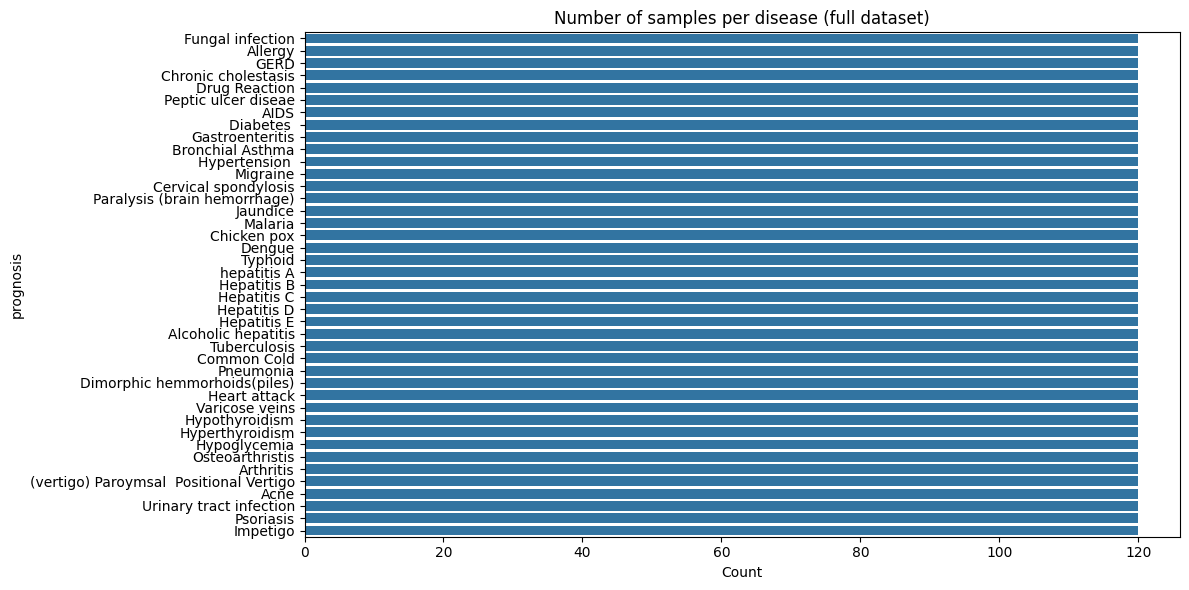

In [20]:
plt.figure(figsize=(12,6))
sns.countplot(y=y, order=y.value_counts().index)
plt.title('Number of samples per disease (full dataset)')
plt.xlabel('Count')
plt.tight_layout()
plt.savefig('Number_of_samples_per_disease_full_dataset.png')
plt.show()

- Each disease appears exactly 120 times (balanced dataset).

- This balance is good for classification without needing class weights.

## **2.2 Frequency Analysis**


| Group | Symptoms Range | Key Observations |
|-------|---------------|------------------|
| **Group 1** (highest frequency) | `itching`, `skin_rash`, `fatigue`, `cough`, etc. | Occur in >2000 patients – common across many diseases (e.g., general infections, allergies). |
| **Group 2** (mid-high) | `mood_swings`, `swelling_join`, `constipation`, etc. | Occur in 500–2000 patients – moderately discriminative. |
| **Group 3** (mid-low) | `blood_stool`, `yell-w_urine`, `cold_hands_and_feet`, etc. | Occur in 100–500 patients – specific to certain conditions. |
| **Group 4** (lowest frequency) | `sunken_eyes`, `skeen_peeling`, `scurring`, etc. | Occur in <100 patients – very rare but highly specific (e.g., advanced disease states). |



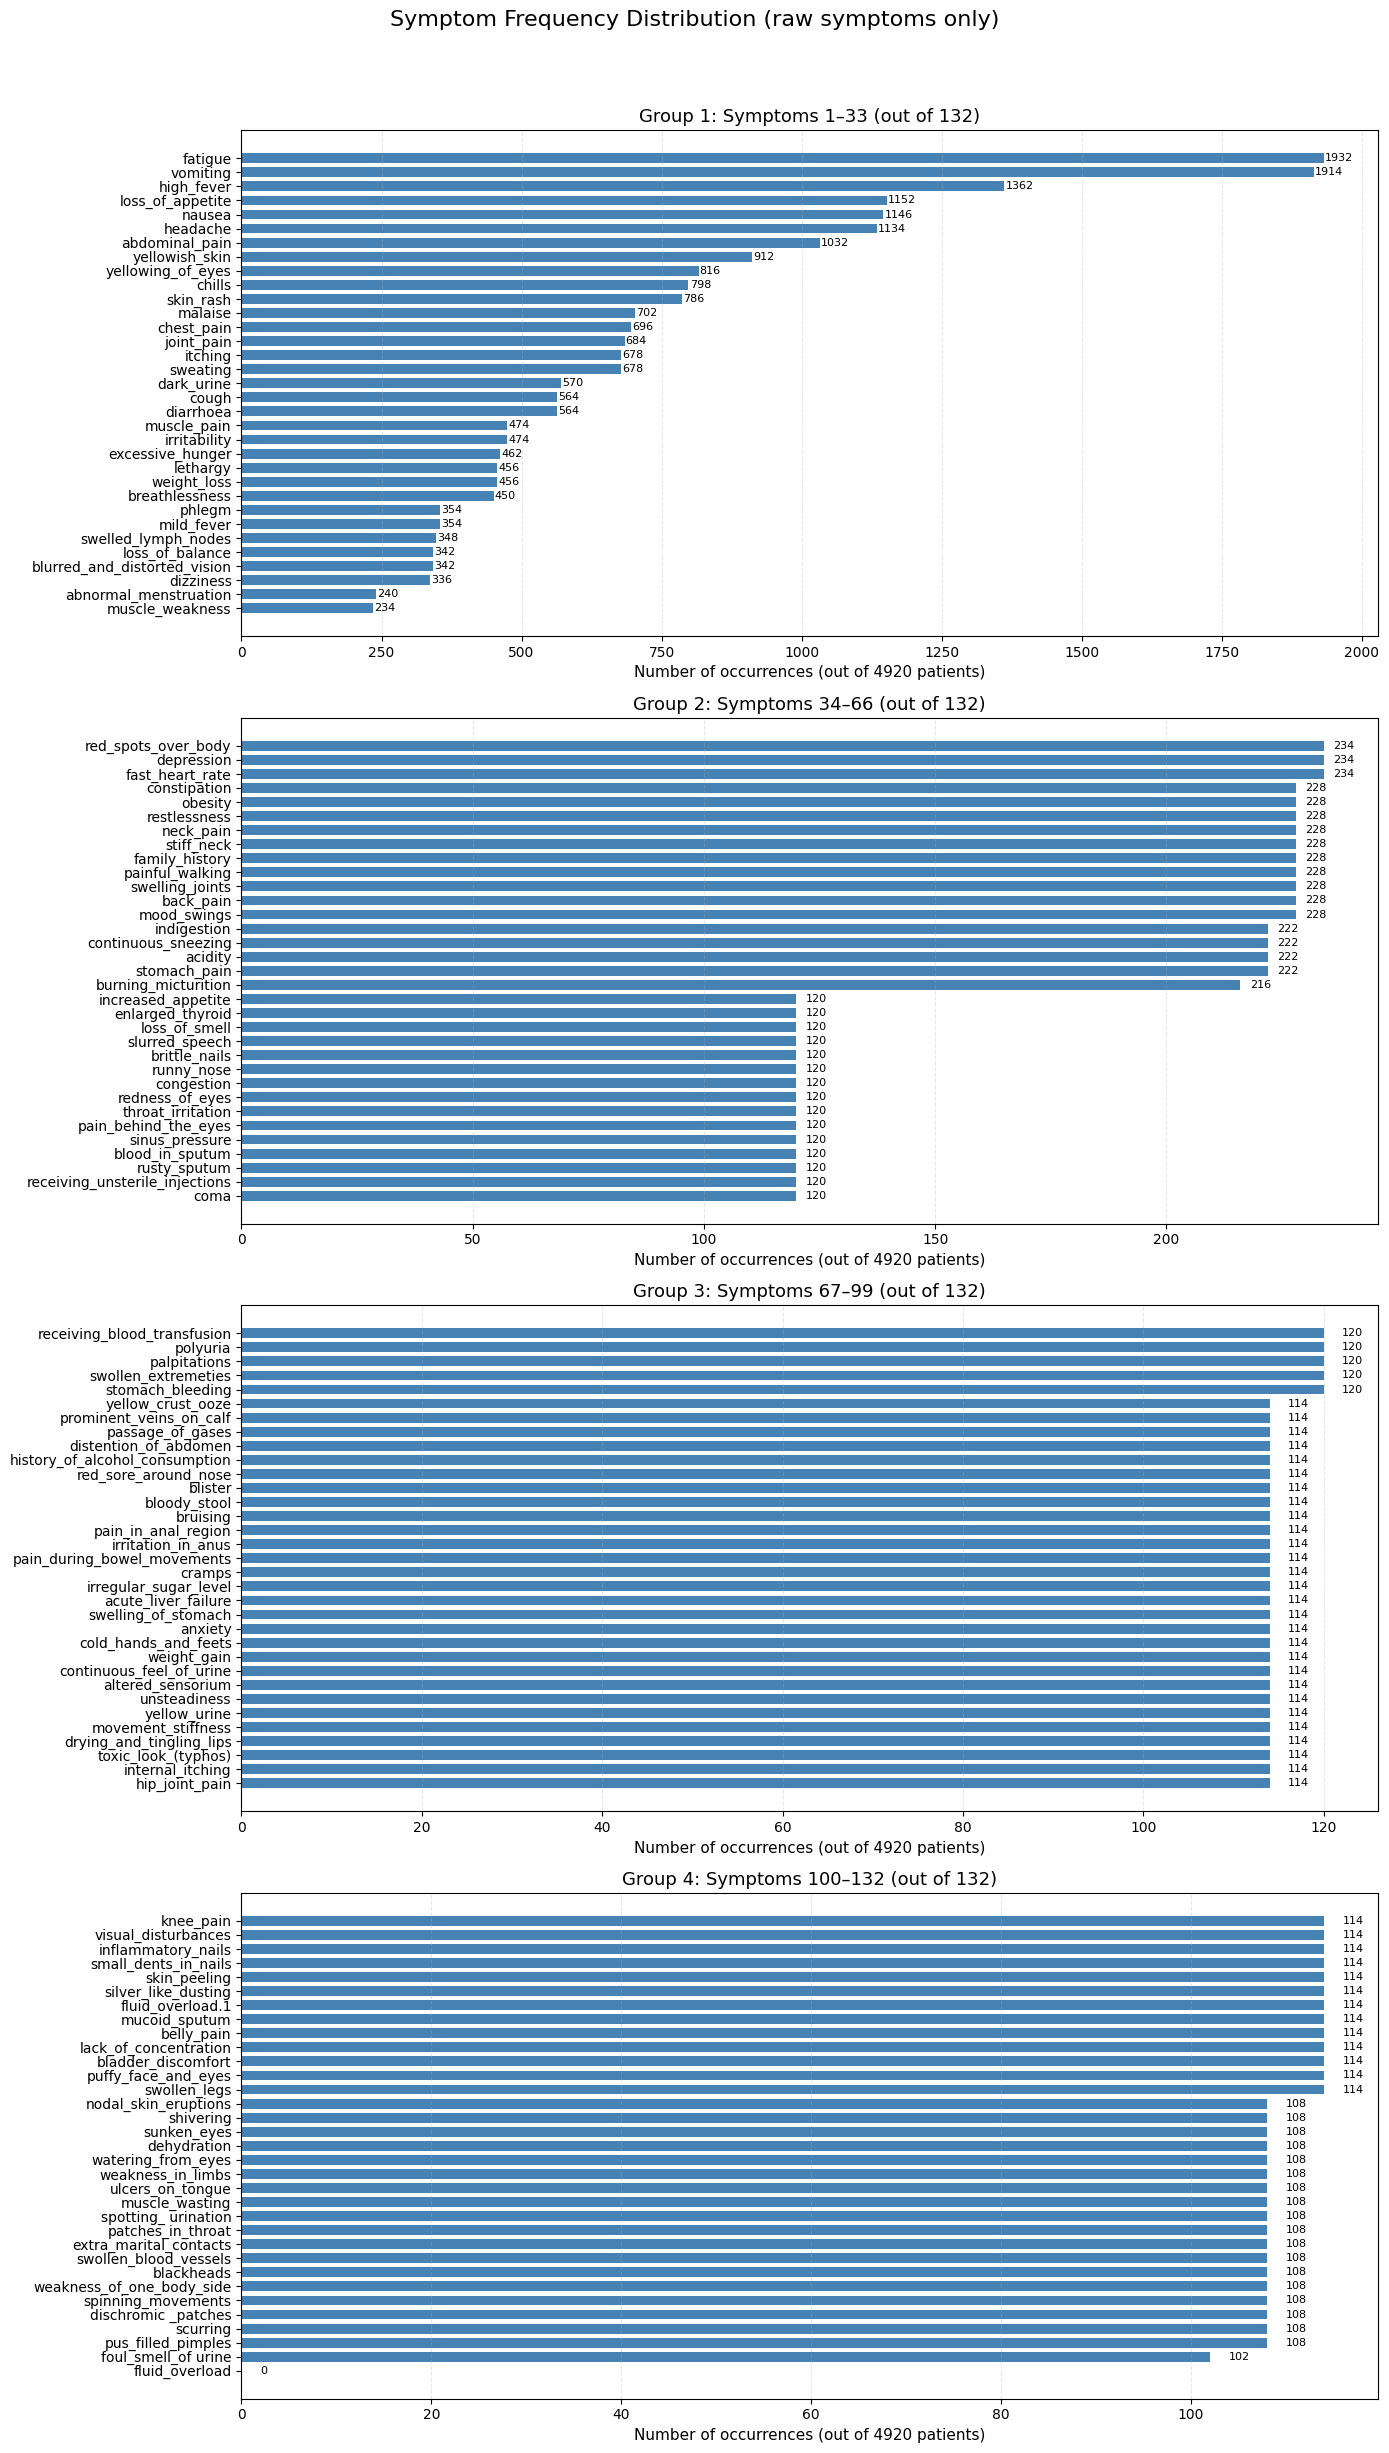

In [21]:


# Ensure we only use the original 132 symptom columns (exclude 'total_symptoms' and 'prognosis')
symptom_cols = [col for col in df.columns if col not in ['prognosis', 'total_symptoms']]
X_raw = df[symptom_cols]

# Symptom counts (full dataset)
symptom_counts = X_raw.sum().sort_values(ascending=False)

# Number of subplots
n_plots = 4
n_symptoms = len(symptom_counts)
symptoms_per_plot = math.ceil(n_symptoms / n_plots)

fig, axes = plt.subplots(n_plots, 1, figsize=(14, n_plots * 6))
fig.suptitle('Symptom Frequency Distribution (raw symptoms only)', fontsize=16, y=1.02)

for i, ax in enumerate(axes):
    start = i * symptoms_per_plot
    end = min((i+1) * symptoms_per_plot, n_symptoms)
    subset = symptom_counts.iloc[start:end]
    
    ax.barh(subset.index, subset.values, color='steelblue', height=0.7)
    ax.set_title(f'Group {i+1}: Symptoms {start+1}–{end} (out of {n_symptoms})', fontsize=13)
    ax.set_xlabel('Number of occurrences (out of 4920 patients)', fontsize=11)
    ax.invert_yaxis()
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    
    # Optional: add value labels on bars (only for clarity)
    for idx, (symptom, value) in enumerate(subset.items()):
        ax.text(value + 2, idx, str(value), va='center', fontsize=8)

plt.tight_layout()
plt.savefig('symptom_frequency_distribution_raw_symptoms_only.png')
plt.show()

## **2.3 Analysis: Disease Composition by Symptom Frequency Groups**
We will:

- Split the 132 symptoms into 4 equal‑sized groups based on their global frequency (as in your subplots).

- For each disease, count how many of its defining symptoms fall into each group.

- Normalise these counts to percentages (so we can compare diseases fairly, regardless of how many symptoms they have).

- Visualise the results as a 100% stacked horizontal bar chart.

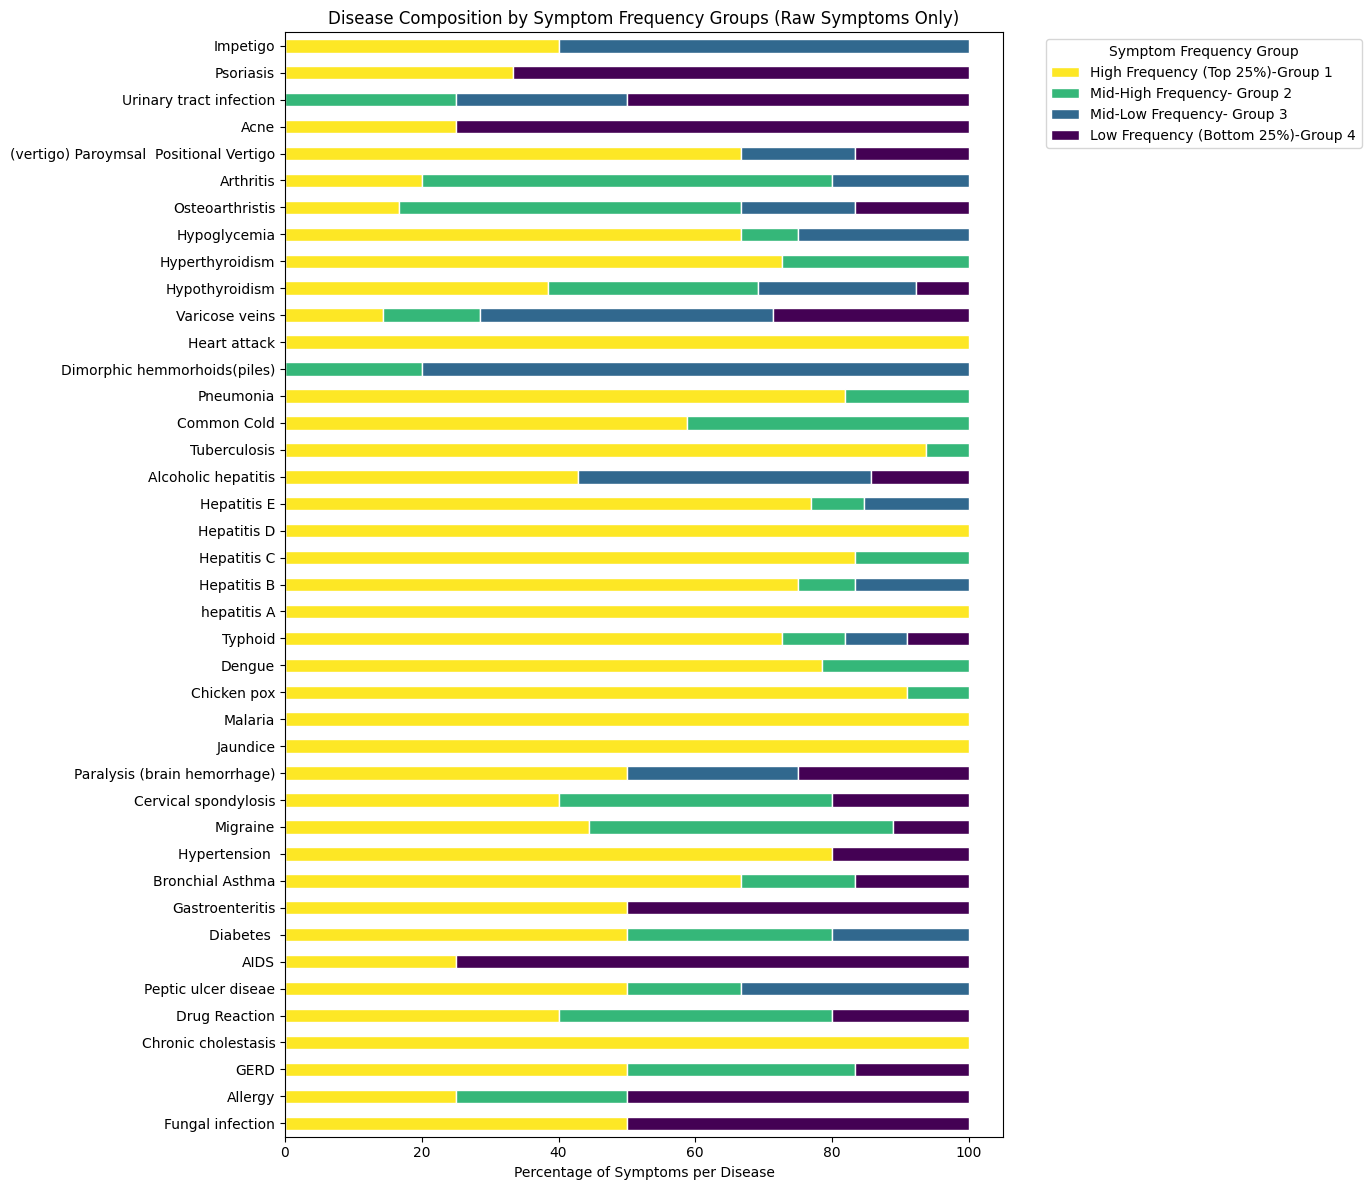

In [22]:


#  Prepare symptom groups (based on global frequency) ---
symptom_cols = [col for col in df.columns if col not in ['prognosis', 'total_symptoms']]
symptom_counts = df[symptom_cols].sum().sort_values(ascending=False)

n = len(symptom_counts)
n_per_group = math.ceil(n / 4)
group_names = ['High Frequency (Top 25%)-Group 1', 'Mid-High Frequency- Group 2', 'Mid-Low Frequency- Group 3', 'Low Frequency (Bottom 25%)-Group 4']
groups = {}

for i in range(4):
    start = i * n_per_group
    end = min((i+1) * n_per_group, n)
    groups[group_names[i]] = symptom_counts.iloc[start:end].index.tolist()

# For each disease, count symptoms in each group ---
disease_group_counts = {name: [] for name in group_names}
disease_list = df['prognosis'].unique()

for disease in disease_list:
    # Sum of symptoms for this disease (over all patients)
    disease_symptoms = df[df['prognosis'] == disease][symptom_cols].sum()
    # Keep symptoms that appear in at least one patient
    present_symptoms = disease_symptoms[disease_symptoms > 0].index.tolist()
    
    for group_name, sym_list in groups.items():
        count = len(set(present_symptoms).intersection(set(sym_list)))
        disease_group_counts[group_name].append(count)

# -Normalise to proportions (percentage) ---
plot_df = pd.DataFrame(disease_group_counts, index=disease_list)
plot_df_norm = plot_df.div(plot_df.sum(axis=1), axis=0) * 100

# -Visualise as 100% stacked bar chart ---
fig, ax = plt.subplots(figsize=(14, 12))
plot_df_norm.plot(kind='barh', stacked=True, ax=ax, colormap='viridis_r', edgecolor='white')
ax.set_xlabel('Percentage of Symptoms per Disease')
ax.set_title('Disease Composition by Symptom Frequency Groups (Raw Symptoms Only)')
ax.legend(title='Symptom Frequency Group', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('disease_composition_by_symptom_frequency_groups_raw_symptoms_only.png')
plt.show()



### **2.3.1 Top 10 diseases relying on symptoms groups**

In [23]:
# ---
print("=" * 60)
print("Diseases relying MOST on LOW-FREQUENCY (Rare) Symptoms:")
print(plot_df_norm['Low Frequency (Bottom 25%)-Group 4'].sort_values(ascending=False).head(10))
print("\n")
      
print("=" * 60)
print("Diseases relying MOST on Mid-Low-FREQUENCY (Group-3) Symptoms:")
print(plot_df_norm['Mid-Low Frequency- Group 3'].sort_values(ascending=False).head(10))
print("\n")
      
print("Diseases relying MOST on MID-HIGH-FREQUENCY (Group-2) Symptoms:")
print(plot_df_norm['Mid-High Frequency- Group 2'].sort_values(ascending=False).head(10))
print("\n")
print("Diseases relying MOST on HIGH-FREQUENCY (Common) Symptoms:")
print(plot_df_norm['High Frequency (Top 25%)-Group 1'].sort_values(ascending=False).head(10))

Diseases relying MOST on LOW-FREQUENCY (Rare) Symptoms:
AIDS                            75.000000
Acne                            75.000000
Psoriasis                       66.666667
Fungal infection                50.000000
Allergy                         50.000000
Gastroenteritis                 50.000000
Urinary tract infection         50.000000
Varicose veins                  28.571429
Paralysis (brain hemorrhage)    25.000000
Drug Reaction                   20.000000
Name: Low Frequency (Bottom 25%)-Group 4, dtype: float64


Diseases relying MOST on Mid-Low-FREQUENCY (Group-3) Symptoms:
Dimorphic hemmorhoids(piles)    80.000000
Impetigo                        60.000000
Alcoholic hepatitis             42.857143
Varicose veins                  42.857143
Peptic ulcer diseae             33.333333
Paralysis (brain hemorrhage)    25.000000
Urinary tract infection         25.000000
Hypoglycemia                    25.000000
Hypothyroidism                  23.076923
Arthritis               

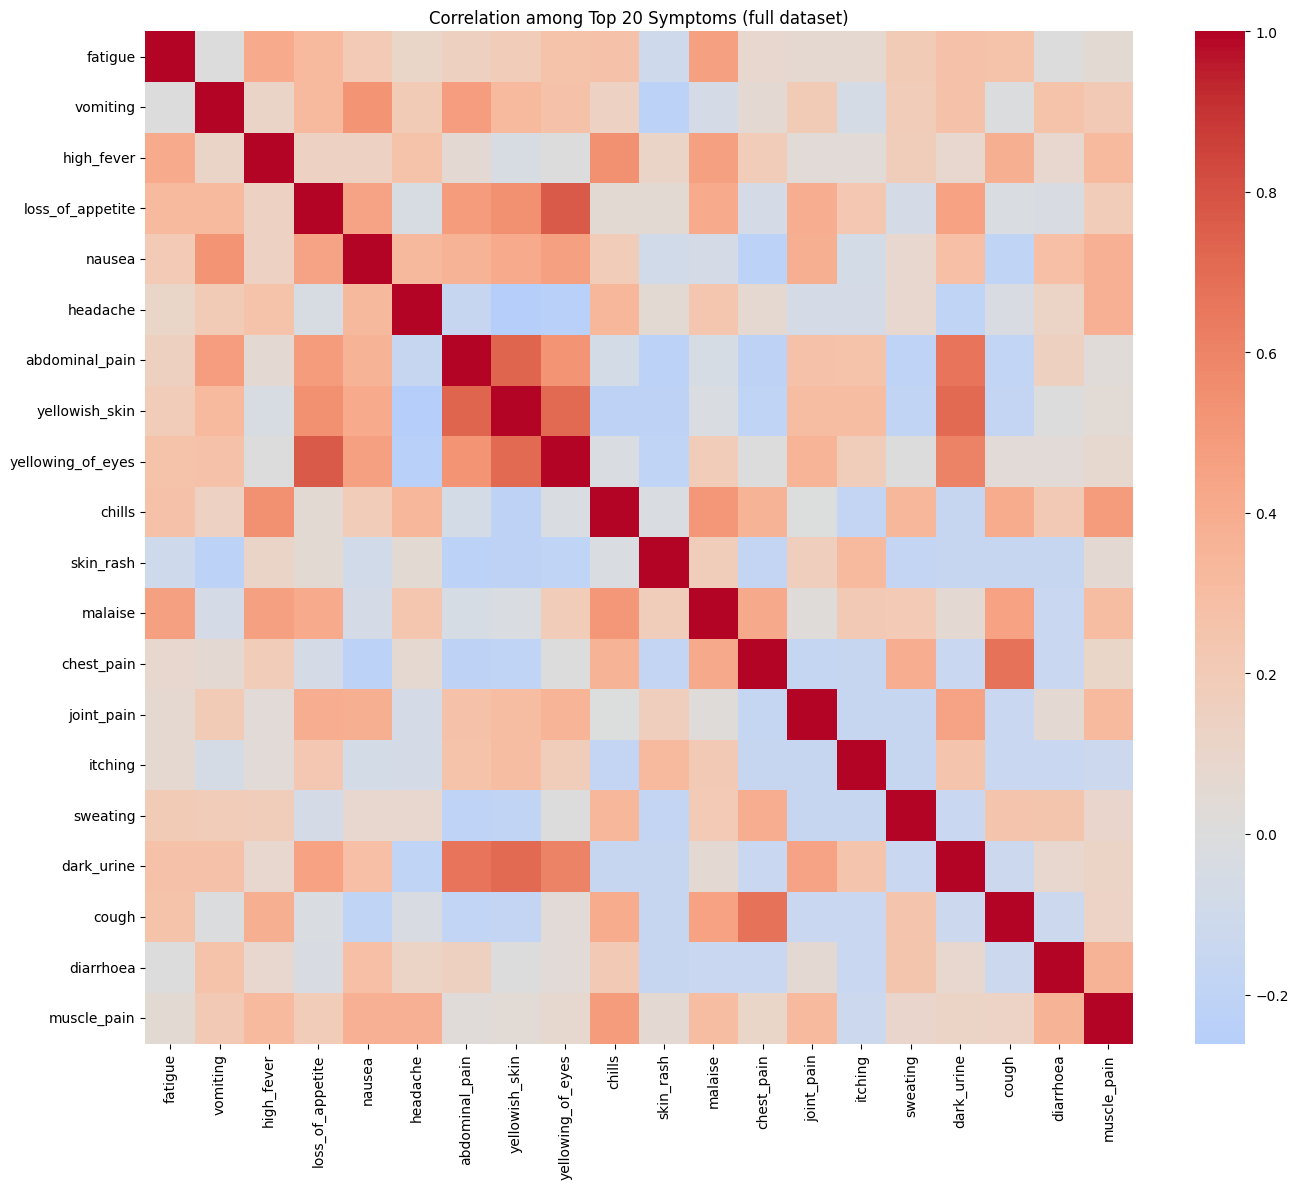

In [24]:
top_symptoms = symptom_counts.head(20).index
X_top = X[top_symptoms]

corr = X_top.corr()

plt.figure(figsize=(14,12))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation among Top 20 Symptoms (full dataset)')
plt.tight_layout()
plt.savefig('Correlation_among_Top_20_Symptoms_full_dataset.png')
plt.show()